In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import psutil

!pip install ftfy pyarrow openpyxl


FIG_DIR = "chronic pain eda visualisations"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches="tight")


**Check column names between file types**

In [56]:

posts_file = "chronic pain data/chronicillness_submissions.ndjson"
comments_file = "chronic pain data/chronicillness_comments.ndjson"

posts = pd.read_json(posts_file, lines=True, nrows=500)
comments = pd.read_json(comments_file, lines=True, nrows=500)

# Check column names
print("BODY in posts?", "body" in posts.columns)
print("BODY in comments?", "body" in comments.columns)

print("\nPost columns:")
print(posts.columns.tolist())

print("\nComment columns:")
print(comments.columns.tolist())

# Shared columns
shared_cols = set(posts.columns).intersection(set(comments.columns))

print("\nShared columns:")
print(sorted(shared_cols))

# Compare key text columns
cols_to_check = ["body", "title", "selftext"]

for col in cols_to_check:
    print(f"\n--- {col} ---")
    print("In posts:", col in posts.columns)
    print("In comments:", col in comments.columns)

    if col in posts.columns:
        print("Posts non-null:", posts[col].notna().sum())
        print("Posts examples:")
        print(posts[col].dropna().head(3).tolist())

    if col in comments.columns:
        print("Comments non-null:", comments[col].notna().sum())
        print("Comments examples:")
        print(comments[col].dropna().head(3).tolist())

BODY in posts? False
BODY in comments? True

Post columns:
['all_awardings', 'allow_live_comments', 'archived', 'author', 'author_created_utc', 'author_flair_background_color', 'author_flair_css_class', 'author_flair_richtext', 'author_flair_template_id', 'author_flair_text', 'author_flair_text_color', 'author_flair_type', 'author_fullname', 'author_patreon_flair', 'author_premium', 'awarders', 'can_gild', 'can_mod_post', 'category', 'content_categories', 'contest_mode', 'created_utc', 'discussion_type', 'distinguished', 'domain', 'edited', 'gilded', 'gildings', 'hidden', 'id', 'is_crosspostable', 'is_meta', 'is_original_content', 'is_reddit_media_domain', 'is_robot_indexable', 'is_self', 'is_video', 'link_flair_background_color', 'link_flair_css_class', 'link_flair_richtext', 'link_flair_text', 'link_flair_text_color', 'link_flair_type', 'locked', 'media', 'media_embed', 'media_only', 'no_follow', 'num_comments', 'num_crossposts', 'over_18', 'parent_whitelist_status', 'permalink', 'pi

**Select Desired Columns**

In [57]:
#Initialise text body and desired columns

all_text = []

cols_wanted = [
    "score", "controversiality",
    "body",
    "author", "id", "link_id", "parent_id",
    "created_utc",
    "title", "selftext", "author_fullname"
]



In [58]:
import os

for file in os.listdir("chronic pain data"):
    size_mb = os.path.getsize(f"chronic pain data/{file}") / 1024**2
    print(f"{file}: {size_mb:.1f} MB")

chronicillness_comments.ndjson: 1019.5 MB
chronicillness_submissions.ndjson: 228.0 MB
chronicpain_comments.ndjson: 2298.7 MB
chronicpain_submissions.ndjson: 328.4 MB


In [59]:

psutil.virtual_memory()

svmem(total=16942211072, available=4663377920, percent=72.5, used=12278833152, free=4663377920)

In [60]:

print(psutil.virtual_memory())

svmem(total=16942211072, available=4652552192, percent=72.5, used=12289658880, free=4652552192)


**Read in RAW Data**

In [61]:

import pyarrow as pa
import pyarrow.parquet as pq

output_file = "chronic_pain_rawdata.parquet"

int_cols = ["score", "controversiality", "created_utc"]
str_cols = [c for c in cols_wanted if c not in int_cols] + ["source_file"]

schema = pa.schema(
    [(c, pa.int64()) for c in int_cols] + [(c, pa.string()) for c in str_cols]
)

writer = pq.ParquetWriter(output_file, schema, compression="snappy")

try:
    for file in os.listdir("chronic pain data"):
        path = f"chronic pain data/{file}"

        for chunk in pd.read_json(path, lines=True, chunksize=100_000, dtype=False):

            for col in cols_wanted:
                if col not in chunk.columns:
                    chunk[col] = None

            temp = chunk[cols_wanted].copy()
            temp["source_file"] = file

            for c in int_cols:
                temp[c] = pd.to_numeric(temp[c], errors="coerce").astype("Int64")
            for c in str_cols:
                temp[c] = temp[c].astype("string")

            table = pa.Table.from_pandas(temp[schema.names], schema=schema, preserve_index=False)
            writer.write_table(table)
finally:
    writer.close()


In [62]:
print(os.path.getsize("chronic_pain_rawdata.parquet")/1024**3, "GB")


0.49608325213193893 GB


In [63]:
# Load the combined raw data file
text_df = pd.read_parquet("chronic_pain_rawdata.parquet")


In [64]:
text_df.memory_usage(deep=True).sum() / 1024**3

np.float64(1.0315636871382594)

*******DATA CLEANING*******

In [65]:
#Aggregated text data

text_df["text"] = (
    text_df["body"].fillna("")
    + text_df["title"].fillna("")
    + text_df["selftext"].fillna("")
)

text_df["text_length"] = text_df["text"].str.len()

In [66]:
rows_before_text_clean = len(text_df)

text_df = text_df[
    text_df["text"].notna()
    & (text_df["text"] != "[deleted]")
    & (text_df["text"] != "[removed]")
]

rows_after_text_clean = len(text_df)

In [67]:
# Remove moderator, bot, and deleted accounts

text_df = text_df[
    ~text_df["author"].str.contains(
        r"AutoModerator|ModTeam|Moderator",
        case=False,
        na=False
    )
]

text_df = text_df[
    text_df["author"] != "[deleted]"
]

print(f"Remaining rows: {len(text_df):,}")

Remaining rows: 1,947,126


In [68]:
#convert utc to calendar time and date

text_df["created_datetime"] = pd.to_datetime(
    text_df["created_utc"],
    unit="s",
    errors="coerce"
)

In [69]:
def extract_age_gender_context(text):
    
    if pd.isna(text):
        return None
    
    pattern = r'(?i)(?:^|\b|\(|\[)(1[3-9]|[2-8]\d|90)\s*[/\-]?\s*([mf])(?:\b|\)|\])'
    match = re.search(pattern, text)
    
    if not match:
        return None
    
    start = max(match.start() - 50, 0)
    end = min(match.end() + 50, len(text))
    
    return text[start:end]

text_df["age_gender_context"] = text_df["body"].apply(extract_age_gender_context)

In [70]:
# Extract age + gender
pattern = r'(?i)(?:^|\b|\(|\[)(1[3-9]|[2-8]\d|90)\s*[/\-]?\s*([mf])(?:\b|\)|\])'

extracted = text_df["body"].str.extract(pattern)
extracted.columns = ["age", "gender"]

text_df["age"] = pd.to_numeric(extracted["age"], errors="coerce")
text_df["gender"] = extracted["gender"].str.upper()


# Extract context around age/gender match
def extract_age_gender_context(text):
    if pd.isna(text):
        return None
    
    match = re.search(pattern, text)
    
    if not match:
        return None
    
    start = max(match.start() - 50, 0)
    end = min(match.end() + 50, len(text))
    
    return text[start:end]

text_df["age_gender_context"] = text_df["body"].apply(extract_age_gender_context)


# View results
text_df.loc[
    text_df["age"].notna(),
    ["body", "age", "gender", "age_gender_context"]
].head(20)

,body,age,gender,age_gender_context
850,"I’m with ya dude, I’ve been going through this...",27.0,F,week and guess what? They found a hernia! (I a...
983,Yes I(28F) have been! Pretty funny bc it’s als...,28.0,F,Yes I(28F) have been! Pretty funny bc it’s als...
2904,I’ve been able to find a meet up group and sup...,28.0,F,I’d always love to make new friends though :) ...
3738,With my experience with chronic illness since ...,20.0,F,nto my disease. Why? Because after six years (...
3898,"I (31F) don’t have GI issues, but have had chr...",31.0,F,"I (31F) don’t have GI issues, but have had chr..."
4321,So not sure if it's relatable but I have had c...,43.0,F,I have had chronic migraines since I was 11. I...
4348,"Man, I relate: 44M, becoming a single dad (div...",44.0,M,"Man, I relate: 44M, becoming a single dad (div..."
4897,"Hey there, I've had similar problems for the l...",27.0,F,t get it (which isn't their fault). It sucks. ...
4907,Hugs. I'm also 24F and I know how it feels to ...,24.0,F,Hugs. I'm also 24F and I know how it feels to ...
5335,I’m (22F) a piano teacher and substitute eleme...,22.0,F,I’m (22F) a piano teacher and substitute eleme...


In [71]:
#Extract Weekday and Hour from time

text_df["created_datetime"] = pd.to_datetime(text_df["created_utc"], unit="s", errors="coerce")

text_df["weekday"] = text_df["created_datetime"].dt.day_name()
text_df["hour"] = text_df["created_datetime"].dt.hour

In [72]:
from ftfy import fix_text

text_df['text'] = text_df['text'].apply(
    lambda x: fix_text(x) if isinstance(x, str) else x
)

In [73]:
text_df.info()

<class 'pandas.DataFrame'>
Index: 1947126 entries, 0 to 2058790
Data columns (total 20 columns):
 #   Column              Dtype        
---  ------              -----        
 0   score               int64        
 1   controversiality    float64      
 2   created_utc         int64        
 3   body                str          
 4   author              str          
 5   id                  str          
 6   link_id             str          
 7   parent_id           str          
 8   title               str          
 9   selftext            str          
 10  author_fullname     str          
 11  source_file         str          
 12  text                str          
 13  text_length         int64        
 14  created_datetime    datetime64[s]
 15  age_gender_context  str          
 16  age                 float64      
 17  gender              str          
 18  weekday             str          
 19  hour                int32        
dtypes: datetime64[s](1), float64(2), int32(1

***EXPLORATION***

In [74]:
#Number of Posts / Comments and Users

n_posts = len(text_df)
n_users = text_df["author"].nunique()

print(f"Posts/comments: {n_posts:,}")
print(f"Unique users: {n_users:,}")

Posts/comments: 1,947,126
Unique users: 139,535


In [75]:
print(f"Removed rowsdue to no text: {rows_before_text_clean - rows_after_text_clean:,}")

Removed rowsdue to no text: 70,821


In [76]:
#Active Users

# Active Users

contribution_summary = (
    text_df
    .groupby("author")
    .agg(
        total_contributions=("author", "size"),
        total_score=("score", "sum"),
        avg_score=("score", "mean"),
        first_post=("created_datetime", "min"),
        last_post=("created_datetime", "max")
    )
    .sort_values("total_contributions", ascending=False)
)

contribution_summary.head(10)

,total_contributions,total_score,avg_score,first_post,last_post
author,,,,,
Old-Goat,18251,59699,3.270999,2020-01-01 22:28:48,2025-12-31 22:31:45
TesseractToo,5812,37763,6.497419,2020-01-03 07:04:17,2025-12-31 20:52:26
Liquidcatz,4984,38478,7.720305,2020-01-02 19:17:18,2025-12-31 19:19:48
CopyUnicorn,4775,17901,3.748901,2021-03-07 17:26:38,2025-09-16 23:30:47
beachbabe77,4329,18368,4.243012,2022-08-18 05:51:41,2025-12-29 18:47:11
Iceprincess1988,4295,24615,5.731083,2022-03-12 15:45:49,2025-12-31 23:57:48
More_Branch_5579,4260,16916,3.970892,2022-06-05 05:53:29,2025-12-31 22:30:35
aiyukiyuu,4053,35437,8.743400,2024-06-02 07:32:45,2025-12-31 08:28:41
HattieLouWho,4038,11633,2.880882,2020-01-02 23:58:07,2023-12-12 12:59:19


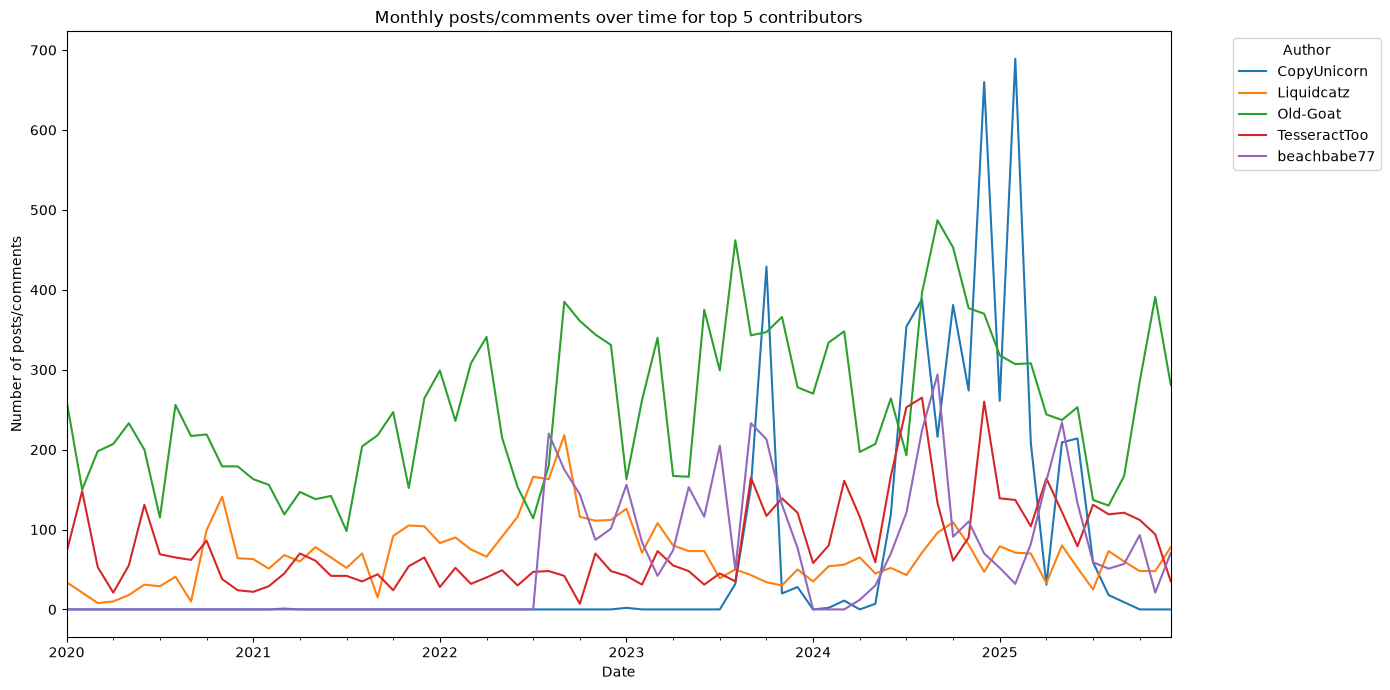

In [77]:
# Plot activity over time for the most active users

top_users = contribution_summary.head(5).index

top_user_activity = (
    text_df[text_df["author"].isin(top_users)]
    .set_index("created_datetime")
    .groupby("author")
    .resample("ME")
    .size()
    .reset_index(name="n_contributions")
)

activity_pivot = top_user_activity.pivot(
    index="created_datetime",
    columns="author",
    values="n_contributions"
).fillna(0)

activity_pivot.plot(figsize=(14, 7))

plt.title("Monthly posts/comments over time for top 5 contributors")
plt.xlabel("Date")
plt.ylabel("Number of posts/comments")
plt.legend(title="Author", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_fig("top_user_trajectories.png")
plt.show()

In [78]:
# Add posting activity duration and rank users

contribution_summary["first_post"] = pd.to_datetime(contribution_summary["first_post"])
contribution_summary["last_post"] = pd.to_datetime(contribution_summary["last_post"])

contribution_summary["posting_duration_days"] = (
    contribution_summary["last_post"] - contribution_summary["first_post"]
).dt.days

contribution_summary["duration_rank"] = (
    contribution_summary["posting_duration_days"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

contribution_summary.sort_values(
    "posting_duration_days",
    ascending=False
).head(20)

,total_contributions,total_score,avg_score,first_post,last_post,posting_duration_days,duration_rank
author,,,,,,,
hawkrt,289,988,3.418685,2020-01-01 04:00:01,2025-12-31 23:09:25,2191,1
Old-Goat,18251,59699,3.270999,2020-01-01 22:28:48,2025-12-31 22:31:45,2191,1
uffdagal,329,1226,3.726444,2020-01-02 05:01:44,2025-12-31 20:40:49,2190,2
Liquidcatz,4984,38478,7.720305,2020-01-02 19:17:18,2025-12-31 19:19:48,2190,2
AnnasOpanas,122,322,2.639344,2020-01-03 02:37:36,2025-12-31 21:48:50,2189,3
CelticSpoonie,339,2033,5.997050,2020-01-01 05:48:08,2025-12-29 17:34:45,2189,3
Kcstarr28,910,3715,4.082418,2020-01-03 12:53:53,2025-12-31 18:03:30,2189,3
mickysti58,1754,5669,3.232041,2020-01-02 20:05:24,2025-12-31 16:42:19,2189,3
TesseractToo,5812,37763,6.497419,2020-01-03 07:04:17,2025-12-31 20:52:26,2189,3


In [79]:
# Proportion of users posting for 1 year or more

n_users = len(contribution_summary)

n_year_plus = (
    contribution_summary["posting_duration_days"] >= 365
).sum()

print(f"{n_year_plus:,} users ({n_year_plus / n_users:.2%}) posted for 1 year or more")

24,894 users (17.84%) posted for 1 year or more


In [80]:
#Propotion of posters with 5+ comments

n_authors = len(contribution_summary)
n_10plus = (contribution_summary["total_contributions"] >= 5).sum()

print(f"{n_10plus} authors ({n_10plus/n_authors:.1%}) have 5+ posts/comments")

47964 authors (34.4%) have 5+ posts/comments


In [81]:
#Random Sampling ages to assess accuracy

sample = text_df[text_df["age"].notna()][
    ["body", "age", "gender", "age_gender_context"]
].sample(100, random_state=42)

sample

,body,age,gender,age_gender_context
1842092,I feel you brother. (33m) 15+ years of undiagn...,33.0,M,I feel you brother. (33m) 15+ years of undiagn...
62813,"Absolutely - IBS, bipolar 2 and OAB here (25F)...",25.0,F,"Absolutely - IBS, bipolar 2 and OAB here (25F)..."
395887,I'm 27f and I work a maximum of 15 hours per w...,27.0,F,I'm 27f and I work a maximum of 15 hours per w...
226279,This happened a while back. Some context that ...,18.0,F,"eeks later, might not have even been that)\n\n..."
459982,"27F, Prozac, Vyvanse, L-Methylfolate, Iron, We...",27.0,F,"27F, Prozac, Vyvanse, L-Methylfolate, Iron, We..."
...,...,...,...,...
1126365,How old are you if you don't mind me asking? I...,20.0,F,y neck I've had this pain for 6 months now :( ...
12123,Im 40m that has same problem only im a type 2 ...,40.0,M,Im 40m that has same problem only im a type 2 ...
142736,You can dm me and we can text. If you decide y...,31.0,F,ide you hate me you can ghost me I guess lol. ...
1067727,That’s the way it works… If the pressure goes ...,26.0,F,er but are stuck in bed in pain. We went down ...


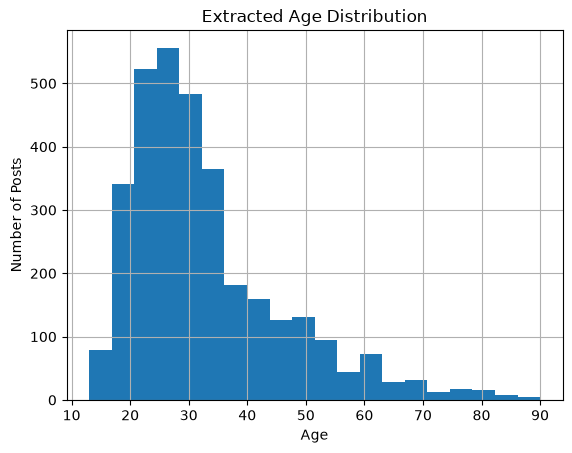

In [82]:
#Age distribution

text_df["age"].hist(bins=20)

plt.title("Extracted Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Posts")
save_fig("age_distribution.png")
plt.show()

In [83]:
#Ages description

text_df['age'].describe()

count    3272.000000
mean       32.912286
std        13.148888
min        13.000000
25%        24.000000
50%        30.000000
75%        38.000000
max        90.000000
Name: age, dtype: float64

In [84]:
#Check older ages

text_df[text_df["age"] >= 70][
    ["body", "age", "gender", "age_gender_context"]
].head(30)

,body,age,gender,age_gender_context
6227,"jesus, sorry to hear this... there is timer's ...",90.0,F,ittle cheap heaters and set them to 28-30C (or...
16604,Yup. I will start getting seriously fatigued a...,80.0,F,Yup. I will start getting seriously fatigued a...
53815,I try to keep a Gatorade or something similar ...,75.0,F,t all times as soon as the temperature goes ab...
55719,My body decided this year that it no longer wa...,70.0,F,direct or indirect sunlight or temperatures ab...
56369,"Low blood pressure, frequent dehydration, inab...",75.0,F,n heat. Any heat. Can’t do anything if it’s ab...
74111,I honestly think that when most people do this...,85.0,F,symptoms when offering me a cup of tea when i...
119946,Honestly so worth it. Literally makes such a h...,78.0,F,am very very heat intolerant (I'll faint if i...
120096,Does it end up affecting your bladder too in a...,78.0,F,"interested in this, since I literally overheat..."
157358,My SIL does this because she’s cold intolerant...,72.0,F,"hat love to cuddle, and she keeps the heat set..."
184136,"No scoliosis, yes on the muscle weakness in my...",80.0,F,"e with the temperature part, like when its alm..."


In [85]:
text_df['body'].loc[119946]

"Honestly so worth it. Literally makes such a huge difference imo. I am very very heat intolerant (I'll faint if it's 78F or above) so it's a necessity haha. \nHope that works for you!"

In [86]:
#Posts per user

user_counts = text_df.groupby("author").size()

print(user_counts.describe())
print("Median: ",user_counts.median())

count    139535.000000
mean         13.954391
std          83.037174
min           1.000000
25%           1.000000
50%           2.000000
75%           7.000000
max       18251.000000
dtype: float64
Median:  2.0


In [87]:
print("Users with 10 or more posts: ", (user_counts >= 10).sum())


Users with 10 or more posts:  29233


In [88]:
#Number of Users with more than 5 Posts

print("Users with 5 or more posts: ", (user_counts >= 5).sum())


Users with 5 or more posts:  47964


In [89]:
#Number of Users with more than 2 posts

print("Users with 2 or more posts: ", (user_counts >= 2).sum())

Users with 2 or more posts:  87414


In [90]:
#Data timeline

print('Data starts: ', text_df["created_datetime"].min())
print('Data ends: ', text_df["created_datetime"].max())

Data starts:  2020-01-01 00:01:30
Data ends:  2025-12-31 23:59:55


hour
0     105517
1     102598
2     101549
3      93374
4      81971
5      70390
6      59104
7      49301
8      42742
9      39606
10     39998
11     47044
12     56871
13     67827
14     78556
15     88000
16     94755
17     99644
18    102007
19    102668
20    106068
21    106426
22    105499
23    105611
dtype: int64


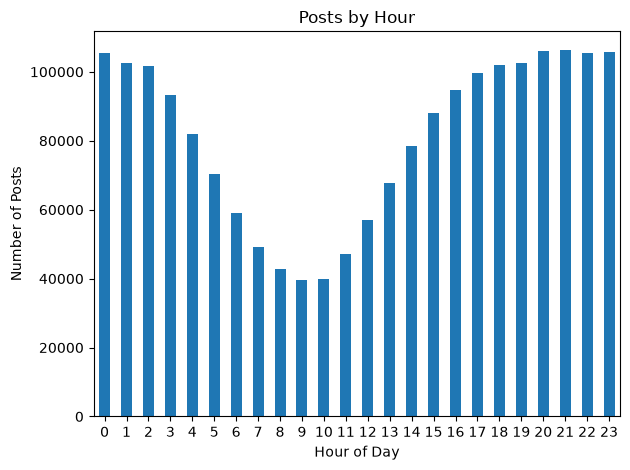

In [91]:
#Posts by hour

text_df["hour"] = text_df["created_datetime"].dt.hour

print(text_df.groupby("hour").size())

posts_by_hour = text_df.groupby("hour").size()

posts_by_hour.plot(kind="bar")

plt.title("Posts by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()
save_fig("posts_by_hour.png")
plt.show()

weekday
Friday       282919
Monday       274751
Saturday     267772
Sunday       267516
Thursday     284366
Tuesday      282874
Wednesday    286928
dtype: int64


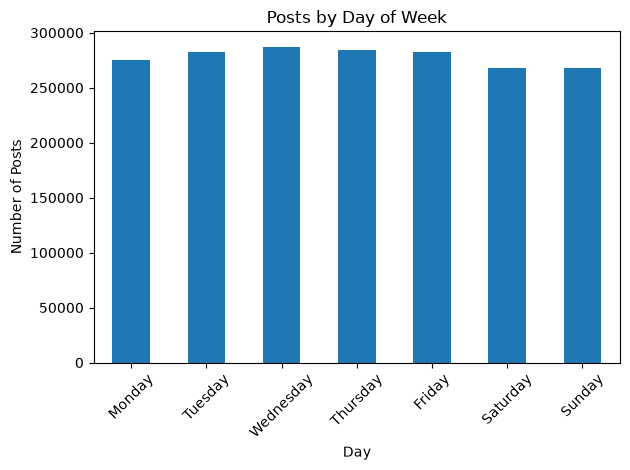

In [92]:
#Posts by day

text_df["weekday"] = text_df["created_datetime"].dt.day_name()

print(text_df.groupby("weekday").size())


weekday_counts = (
    text_df.groupby("weekday")
    .size()
    .reindex(
        ["Monday", "Tuesday", "Wednesday", "Thursday",
         "Friday", "Saturday", "Sunday"]
    )
)


# Bar chart
weekday_counts.plot(kind="bar")

plt.title("Posts by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("posts_by_weekday.png")
plt.show()

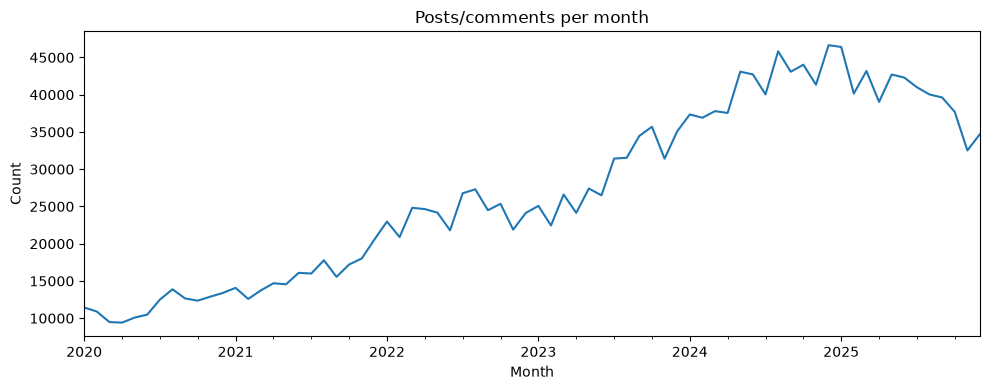

In [93]:
#posts by month

monthly_posts = (
    text_df
    .set_index("created_datetime")
    .resample("ME")
    .size()
)

monthly_posts.plot(
    kind="line",
    figsize=(10, 4),
    title="Posts/comments per month",
    xlabel="Month",
    ylabel="Count"
)

plt.tight_layout()
save_fig("posts_per_month.png")
plt.show()


In [94]:
#Score overview

text_df["score"].describe()

count    1.947126e+06
mean     5.584083e+00
std      2.340485e+01
min     -3.110000e+02
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      2.872000e+03
Name: score, dtype: float64

In [95]:
#Highest rated posts

text_df.nlargest(10, "score")

,score,controversiality,created_utc,body,author,id,link_id,parent_id,title,selftext,author_fullname,source_file,text,text_length,created_datetime,age_gender_context,age,gender,weekday,hour
2036006,2872,NaN,1733779564,NaN,Elyay,1hakvo3,NaN,NaN,He either had chronic pain or knew someone who...,I followed the news on this as much as anyone ...,t2_qxqz0,chronicpain_submissions.ndjson,He either had chronic pain or knew someone who...,153,2024-12-09 21:26:04,NaN,NaN,NaN,Monday,21
2050847,2814,NaN,1754834829,NaN,Strong_Wild_Power,1mmjhnu,NaN,NaN,I lost my sister last week due too suicide bec...,,t2_nerp5dsb,chronicpain_submissions.ndjson,I lost my sister last week due too suicide bec...,263,2025-08-10 14:07:09,NaN,NaN,NaN,Sunday,14
2039001,1881,NaN,1737922981,NaN,leosousa66,1iap83d,NaN,NaN,I wish people understood this,,t2_11mlly,chronicpain_submissions.ndjson,I wish people understood this,29,2025-01-26 20:23:01,NaN,NaN,NaN,Sunday,20
2049715,1795,NaN,1753307465,NaN,Extension-Conscious,1m7mds0,NaN,NaN,I feel like this might actually work???,,t2_5ifq9d9t,chronicpain_submissions.ndjson,I feel like this might actually work???,39,2025-07-23 21:51:05,NaN,NaN,NaN,Wednesday,21
2037117,1751,NaN,1735179257,NaN,magesticcowfairy92,1hmeks1,NaN,NaN,This!,,t2_6ncl96k8,chronicpain_submissions.ndjson,This!,6,2024-12-26 02:14:17,NaN,NaN,NaN,Thursday,2
2029226,1686,NaN,1723921472,NaN,coleisw4ck,1eupaud,NaN,NaN,literally this,,t2_s0qmt0q4,chronicpain_submissions.ndjson,literally this,15,2024-08-17 19:04:32,NaN,NaN,NaN,Saturday,19
2051668,1686,NaN,1755997979,NaN,HorrorQueen921314,1myijnk,NaN,NaN,This!,,t2_1gtwv56rmo,chronicpain_submissions.ndjson,This!,5,2025-08-24 01:12:59,NaN,NaN,NaN,Sunday,1
2036949,1680,NaN,1734929663,NaN,Top_Use4144,1hkgfz6,NaN,NaN,Everyday I'm sure we all think this.,Anon from IG.\nThis is why I like this sub..it...,t2_dn33pza9,chronicpain_submissions.ndjson,Everyday I'm sure we all think this.Anon from ...,225,2024-12-23 04:54:23,NaN,NaN,NaN,Monday,4
2044132,1680,NaN,1745607619,NaN,HorrorQueen921314,1k7sxgr,NaN,NaN,This!,,t2_1gtwv56rmo,chronicpain_submissions.ndjson,This!,5,2025-04-25 19:00:19,NaN,NaN,NaN,Friday,19
2044609,1651,NaN,1746308106,NaN,HorrorQueen921314,1ke3svo,NaN,NaN,This!,,t2_1gtwv56rmo,chronicpain_submissions.ndjson,This!,5,2025-05-03 21:35:06,NaN,NaN,NaN,Saturday,21


In [96]:
#Score Description

print(text_df['score'].describe())
print('Median: ', text_df['score'].median())

count    1.947126e+06
mean     5.584083e+00
std      2.340485e+01
min     -3.110000e+02
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      2.872000e+03
Name: score, dtype: float64
Median:  2.0


In [97]:
#Text overview

print(text_df["text_length"].describe())
print('Median Length', text_df['text_length'].median())

count    1.947126e+06
mean     3.771447e+02
std      5.581709e+02
min      0.000000e+00
25%      8.300000e+01
50%      2.010000e+02
75%      4.490000e+02
max      6.091200e+04
Name: text_length, dtype: float64
Median Length 201.0


In [98]:
#How many replies to comments we have

text_df["parent_id"].notna().mean()

np.float64(0.9261290743382812)

In [99]:
#Comments vs Posts split

print("Comments: ",text_df["body"].notna().sum())
print("Posts: ",text_df["title"].notna().sum())

Comments:  1803290
Posts:  143836


In [100]:
#Check for null lines incase no textual data to copy

text_df["text"].isna().sum()

np.int64(0)

**Export data to parquet**

In [101]:

text_df.to_parquet("ChronicPainData.parquet", index=False)


**Create Sample for Annotating**

In [102]:
# Randomly sample 250 rows with at least 5 words and 20 characters

text_col = "text"

eligible_df = text_df[
    text_df[text_col].notna()
    & (text_df[text_col].astype(str).str.split().str.len() >= 5)
    & (text_df[text_col].astype(str).str.len() >= 20)
].copy()

sample_250 = eligible_df.sample(
    n=250,
    random_state=42
).copy()

annotation_cols = [
    "sensory",
    "emotional",
    "behavioural",
    "cognitive"
]

for col in annotation_cols:
    sample_250[col] = ""

annot_file = "chronicannotation_sample_250.csv"
if os.path.exists(annot_file):
    print(f"{annot_file} already exists - not overwriting (delete it first to regenerate)")
else:
    sample_250.to_csv(annot_file, index=False, encoding="utf-8-sig")

print(f"Eligible rows: {len(eligible_df)}")
print(f"Sampled rows: {len(sample_250)}")

sample_250.head()

Eligible rows: 1815420
Sampled rows: 250


,score,controversiality,created_utc,body,author,id,link_id,parent_id,title,selftext,...,created_datetime,age_gender_context,age,gender,weekday,hour,sensory,emotional,behavioural,cognitive
602432,1,NaN,1684982913,NaN,Fit_Abrocoma_3482,13r5tol,NaN,NaN,My life feels like a lost dream…,[removed],...,2023-05-25 02:48:33,NaN,NaN,NaN,Thursday,2,,,,
896483,3,0.0,1644815535,"I've gotten Zofran and Metformin. Both worked,...",motherdragon02,hwvir0l,t3_srwpdp,t1_hwunuln,NaN,NaN,...,2022-02-14 05:12:15,NaN,NaN,NaN,Monday,5,,,,
916772,1,0.0,1648164510,I got a bunch of bloodwork done to look for in...,Sweet-Travel-4657,i1zwylc,t3_tmvdan,t1_i1zwb8o,NaN,NaN,...,2022-03-24 23:28:30,NaN,NaN,NaN,Thursday,23,,,,
1583161,1,0.0,1733246417,Nice hope your appt goes well. Yeah stopping B...,Jolly_Mixture_75,m08896w,t3_1g0gl7t,t1_m06znlk,NaN,NaN,...,2024-12-03 17:20:17,NaN,NaN,NaN,Tuesday,17,,,,
582889,2,NaN,1615937819,NaN,Bonki__uwu,m6mmmf,NaN,NaN,Fibromyalgia chest and back pain?,"Does anyone have bad chest, back and upper sto...",...,2021-03-16 23:36:59,NaN,NaN,NaN,Tuesday,23,,,,


*Combinining Sample Datasets for Annotating*

In [103]:
# Replace these with your actual file names
file_1 = "cancerannotation_sample_250.csv"
file_2 = "chronicannotation_sample_250.csv"

df1 = pd.read_csv(file_1, encoding="utf-8-sig")
df2 = pd.read_csv(file_2, encoding="utf-8-sig")

# Combine rows into one dataframe
combined_df = pd.concat([df1, df2], ignore_index=True)



# Save combined file for annotating
combined_df.to_csv("combined_annotation_sample.csv", index=False, encoding="utf-8-sig")



print(f"File 1 rows: {len(df1)}")
print(f"File 2 rows: {len(df2)}")
print(f"Combined rows: {len(combined_df)}")

combined_df.head()

File 1 rows: 250
File 2 rows: 250
Combined rows: 500


,score,controversiality,created_utc,body,author,id,link_id,parent_id,title,selftext,...,created_datetime,age,gender,age_gender_context,weekday,hour,sensory,emotional,behavioural,cognitive
0,1,0.0,1755472506,The links too… thank you angel! This is great,Thin_Shape7184,n99cqi4,t3_1mt3h3b,t1_n991d4e,NaN,NaN,...,2025-08-17 23:15:06,NaN,NaN,NaN,Sunday,23,NaN,NaN,NaN,NaN
1,1,0.0,1629469899,Please don't post unless you have been diagnos...,Tapir_Tabby,h9nztnr,t3_p84ri1,t3_p84ri1,NaN,NaN,...,2021-08-20 14:31:39,NaN,NaN,NaN,Friday,14,NaN,NaN,NaN,NaN
2,2,NaN,1644767686,NaN,ExplanationPurple809,srlp6f,NaN,NaN,Anyone know what this is?,"Came out of nowhere about 6-4 weeks ago, doesn...",...,2022-02-13 15:54:46,NaN,NaN,NaN,Sunday,15,NaN,NaN,NaN,NaN
3,2,0.0,1765674621,That's good. Did you have any pos nodes in you...,NurseYuna,ntwmjcn,t3_1plwx00,t1_ntw7uow,NaN,NaN,...,2025-12-14 01:10:21,NaN,NaN,NaN,Sunday,1,NaN,NaN,NaN,NaN
4,1,0.0,1604572608,It got much worse and no clippings were taken ...,anonym00213,gb7sb8f,t3_jnhtt4,t1_gb70c6k,NaN,NaN,...,2020-11-05 10:36:48,NaN,NaN,NaN,Thursday,10,NaN,NaN,NaN,NaN


**Convert back to Parquet after annotating**

In [104]:

# Once labelling is finished, convert to Parquet for the BERT notebooks:
#labelled = pd.read_csv("combined_annotation_sample.csv", encoding="utf-8-sig")
#labelled.to_parquet("combined_annotation_labelled.parquet", index=False)